In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [11]:
df = pd.read_csv("../data/train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [12]:
df.info()

# Converter data
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d/%m/%Y")

# Criar coluna de mês
df['Month'] = df['Order Date'].dt.month

# Ver nulos
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Month             0
dtype: int64

In [13]:
total_revenue = df['Sales'].sum()
print(f"Receita total: {total_revenue}")

Receita total: 2261536.7827


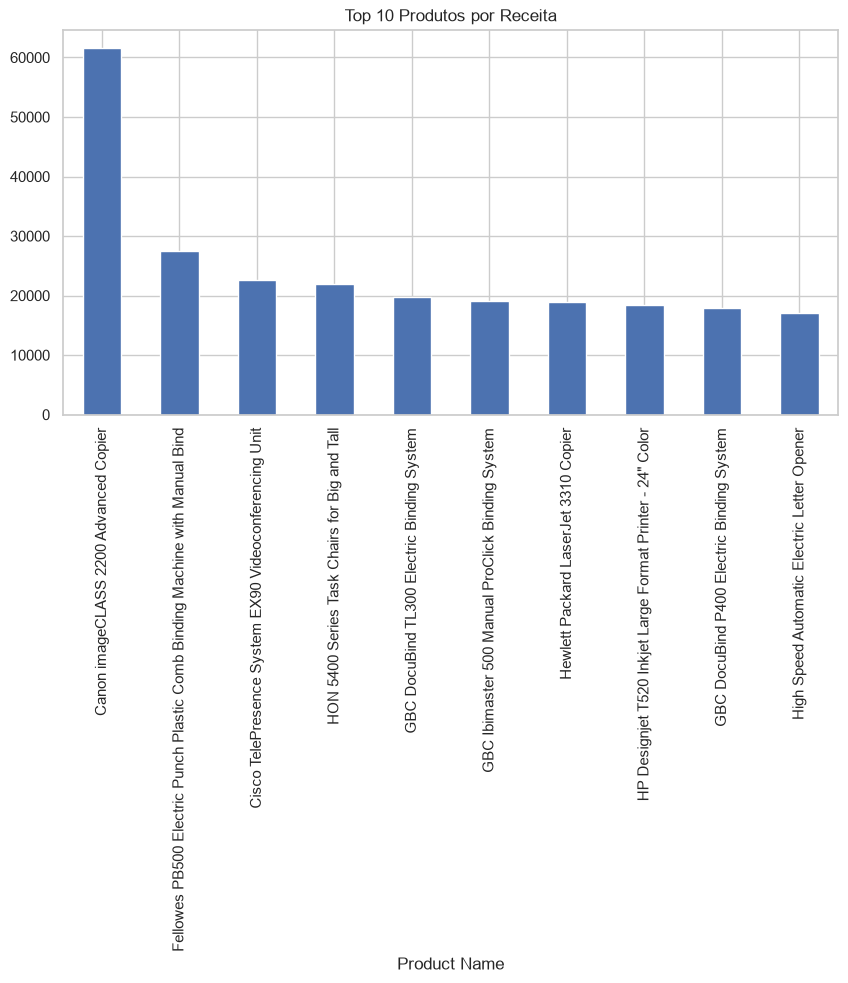

In [14]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Produtos por Receita")
plt.show()

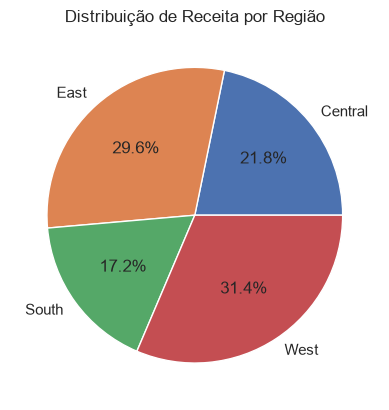

In [15]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribuição de Receita por Região")
plt.show()

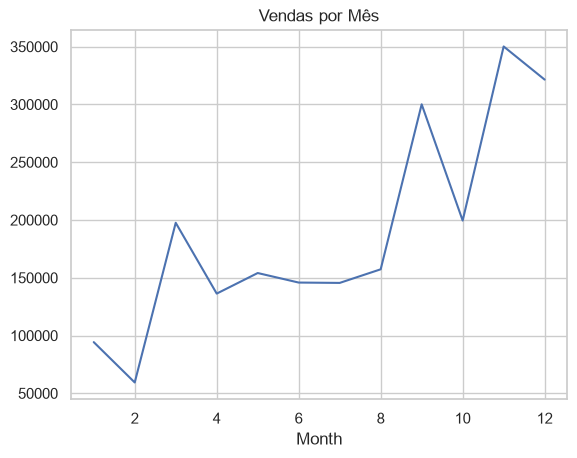

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Vendas por Mês")
plt.show()
plt.savefig('../images/grafico_vendas.png')

<Axes: xlabel='YearMonth'>

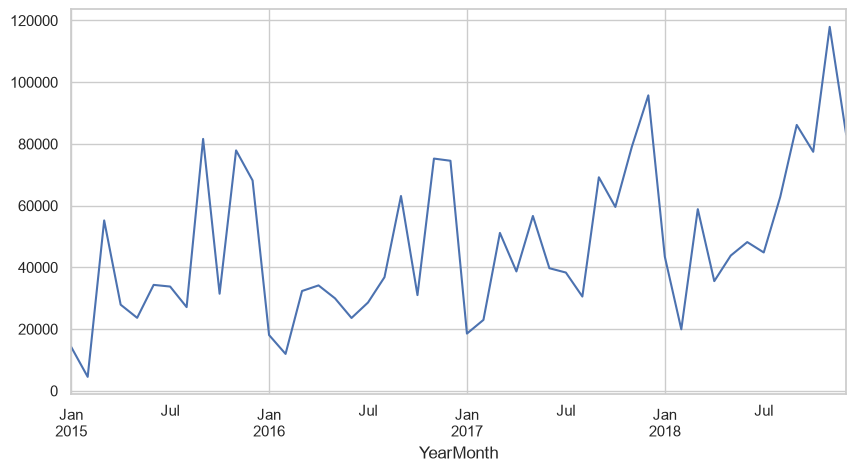

In [17]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Sales'].sum()

monthly_sales.plot(figsize=(10,5))

## Insights

- A região West concentra a maior parte da receita, indicando forte desempenho comercial e maior penetração de mercado nessa região

- O produto Canon imageCLASS 2200 Advanced Copier é o principal responsável pelo faturamento, sugerindo alta demanda por itens de maior valor agregado

- Há um padrão claro de sazonalidade, com aumento significativo nas vendas nos meses 11 e 12, possivelmente impulsionado por eventos de fim de ano e maior atividade comercial

- A região South apresenta menor volume de vendas, indicando uma oportunidade estratégica para ações de expansão, marketing ou otimização da operação comercial